### 1) Importing required libraries

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2) Loading the dataset

In [154]:
df = pd.read_csv('Google_Ad_dataset.csv')

##Reviewing the first few rows of dataset
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


### 3) Checking the columns name for any inconsistencies

In [155]:
df.columns.tolist()

#lowering all the columns name and replace the space between words with '_'
df.columns = df.columns.str.lower().str.replace(' ','_')
df.head()

,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


### 4) Removing dollar sign for cost and sale_amount column and fixing the date format

In [156]:

#Fixing the dollar sign
df['cost'] = df['cost'].replace('[$]',' ',regex = True)
df['sale_amount'] = df['sale_amount'].replace('[$]', ' ',regex = True)

#Fixing the date format
df['ad_date'] = pd.to_datetime(df['ad_date'], errors = 'coerce')

df.info()



<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ad_id            2600 non-null   str           
 1   campaign_name    2600 non-null   str           
 2   clicks           2488 non-null   float64       
 3   impressions      2546 non-null   float64       
 4   cost             2503 non-null   str           
 5   leads            2552 non-null   float64       
 6   conversions      2526 non-null   float64       
 7   conversion_rate  1974 non-null   float64       
 8   sale_amount      2461 non-null   str           
 9   ad_date          893 non-null    datetime64[us]
 10  location         2600 non-null   str           
 11  device           2600 non-null   str           
 12  keyword          2600 non-null   str           
dtypes: datetime64[us](1), float64(5), str(7)
memory usage: 445.9 KB


### 5) Checking for inconsistencies in data type of each columns

In [157]:
df.info()
##Converting the data type of numeric columns to numeric data type
numeric_columns = [
    'clicks',
    'impressions',
    'cost',
    'leads',
    'conversions',
    'conversion_rate',
    'sale_amount'
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column],errors='coerce')
print('\nAfter cleaning insconsistencies in data type:\n')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ad_id            2600 non-null   str           
 1   campaign_name    2600 non-null   str           
 2   clicks           2488 non-null   float64       
 3   impressions      2546 non-null   float64       
 4   cost             2503 non-null   str           
 5   leads            2552 non-null   float64       
 6   conversions      2526 non-null   float64       
 7   conversion_rate  1974 non-null   float64       
 8   sale_amount      2461 non-null   str           
 9   ad_date          893 non-null    datetime64[us]
 10  location         2600 non-null   str           
 11  device           2600 non-null   str           
 12  keyword          2600 non-null   str           
dtypes: datetime64[us](1), float64(5), str(7)
memory usage: 445.9 KB

After cleaning insconsistencies in data

### 6) Checking for inconsistencies in the values in string columns and fixing them

In [158]:
##For the column named "campaign_name"
df['campaign_name'].value_counts()

#Fixing
df['campaign_name'] = df['campaign_name'].replace({
    'Data Analytcis Course':'data analytics course',
    'Data Analytics Corse':'data analytics course',
    'DataAnalyticsCourse':'data analytics course',
    'Data Anlytics Corse':'data analytics course'
})
print('After fixing the name:')
df.head()

After fixing the name:


,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,NaT,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,NaT,hyderabad,Desktop,data analitics online
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,hyderabad,desktop,online data analytic


In [159]:
##For the column named "location"
df['location'].value_counts()

#Fixing
df['location'] = df['location'].str.lower().str.strip().replace({
    'hyderbad':'hyderabad',
    'hydrebad':'hyderabad'
})
df['location'].value_counts()
print('After fixing name of location:')
df.head(10)

After fixing name of location:


,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,NaT,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,NaT,hyderabad,Desktop,data analitics online
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,hyderabad,tablet,data anaytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,hyderabad,desktop,online data analytic
5,A1005,data analytics course,195.0,3776.0,243.57,10.0,8.0,NaN,1315.0,NaT,hyderabad,MOBILE,data anaytics training
6,A1006,data analytics course,116.0,4480.0,237.79,17.0,5.0,0.043,1640.0,NaT,hyderabad,TABLET,data analytics course
7,A1007,data analytics course,184.0,5060.0,229.61,23.0,3.0,0.016,1509.0,NaT,hyderabad,TABLET,analytics for data
8,A1008,data analytics course,113.0,5434.0,NaN,27.0,4.0,0.058,1362.0,NaT,hyderabad,Tablet,data anaytics training
9,A1009,data analytics course,166.0,3355.0,186.78,24.0,9.0,0.054,1029.0,NaT,hyderabad,Mobile,online data analytic


In [160]:
## Lowering the name of device in 'device column values
df['device'].value_counts()

#Fixing
df['device'] = df['device'].str.lower()
df['device'].value_counts()
df.head(10)

,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,NaT,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,NaT,hyderabad,desktop,data analitics online
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,hyderabad,tablet,data anaytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,hyderabad,desktop,online data analytic
5,A1005,data analytics course,195.0,3776.0,243.57,10.0,8.0,NaN,1315.0,NaT,hyderabad,mobile,data anaytics training
6,A1006,data analytics course,116.0,4480.0,237.79,17.0,5.0,0.043,1640.0,NaT,hyderabad,tablet,data analytics course
7,A1007,data analytics course,184.0,5060.0,229.61,23.0,3.0,0.016,1509.0,NaT,hyderabad,tablet,analytics for data
8,A1008,data analytics course,113.0,5434.0,NaN,27.0,4.0,0.058,1362.0,NaT,hyderabad,tablet,data anaytics training
9,A1009,data analytics course,166.0,3355.0,186.78,24.0,9.0,0.054,1029.0,NaT,hyderabad,mobile,online data analytic


In [161]:
## checking for inconsitencies in the column named 'keyword'ArithmeticError
# df['keyword'].value_counts()

#Fixing
df['keyword'] = df['keyword'].replace({
    'online data analytic':'online data analytics',
    'analytics for data':'data analytics',
    'data analitics online':'online data analytics',
    'data analytics trainin':'data analytics training'
})
df['keyword'].value_counts()
print('After fixing the name of keyword: ')
df.head(10)

After fixing the name of keyword: 


,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,NaT,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,NaT,hyderabad,desktop,online data analytics
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,hyderabad,tablet,data anaytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,hyderabad,desktop,online data analytics
5,A1005,data analytics course,195.0,3776.0,243.57,10.0,8.0,NaN,1315.0,NaT,hyderabad,mobile,data anaytics training
6,A1006,data analytics course,116.0,4480.0,237.79,17.0,5.0,0.043,1640.0,NaT,hyderabad,tablet,data analytics course
7,A1007,data analytics course,184.0,5060.0,229.61,23.0,3.0,0.016,1509.0,NaT,hyderabad,tablet,data analytics
8,A1008,data analytics course,113.0,5434.0,NaN,27.0,4.0,0.058,1362.0,NaT,hyderabad,tablet,data anaytics training
9,A1009,data analytics course,166.0,3355.0,186.78,24.0,9.0,0.054,1029.0,NaT,hyderabad,mobile,online data analytics


In [162]:
##Checking unique campaigns name
df['campaign_name'].value_counts()

##Fixing the inconsistencies in campaign name
df['campaign_name'] = df['campaign_name'].replace({
    'Data Analytics Corse':'Data Analytics Course',
    'DataAnalyticsCourse':'Data Analytics Course',
    'Data Anlytics Corse':'Data Analytics Course',
    'Data Analytcis Course':'Data Analytics Course'
})
df.head()

,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,NaT,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,NaT,hyderabad,desktop,online data analytics
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,hyderabad,tablet,data anaytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,hyderabad,desktop,online data analytics


In [163]:
##Checking the unique names for location column
df['location'].value_counts()

##Fixing the inconsitencies in the name of the location
df['location'] = df['location'].replace({
    'hyderbad':'hyderabad',
    'hydrebad':'hyderabad'
})
df.head()

,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,NaT,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,NaT,hyderabad,desktop,online data analytics
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,hyderabad,tablet,data anaytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,hyderabad,desktop,online data analytics


In [164]:
##checking the unique values in the device column to check for any inconsistencies
df['device'].value_counts()

device
desktop    888
mobile     878
tablet     834
Name: count, dtype: int64

In [165]:
##Cheecking for any inconsitencies in the column named 'keyword/
df['keyword'].value_counts()

##Fixing the inconsitencies
df['keyword'] = df['keyword'].replace({
    'online data analytic':'online data analytics',
    'analytics for data':'data analytics',
    'data analitics online':'data analytics online',
    'data anaytics training':'data analytics training'
})
df.head()

,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,NaT,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,NaT,hyderabad,desktop,online data analytics
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,hyderabad,tablet,data analytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,hyderabad,desktop,online data analytics


### 7) Checking for Null values

In [166]:
df.isnull().sum()

#Handling missing values for each column
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())
#for ad_date column
if df['ad_date'].isnull().sum() > 0:
    df['ad_date'] = df['ad_date'].fillna(df['ad_date'].mode()[0])
df.head()

,ad_id,campaign_name,clicks,impressions,cost,leads,conversions,conversion_rate,sale_amount,ad_date,location,device,keyword
0,A1000,data analytics course,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,2024-11-14,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90.0,4544.0,203.66,26.0,9.0,0.046,1624.0,2024-11-14,hyderabad,desktop,online data analytics
3,A1003,data analytics course,142.0,3185.0,237.66,17.0,6.0,0.046,1225.0,2024-11-26,hyderabad,tablet,data analytics training
4,A1004,data analytics course,156.0,3361.0,195.90,30.0,8.0,0.046,1091.0,2024-11-22,hyderabad,desktop,online data analytics


In [167]:
##Check final missing values if any
df.isnull().sum()

ad_id              0
campaign_name      0
clicks             0
impressions        0
cost               0
leads              0
conversions        0
conversion_rate    0
sale_amount        0
ad_date            0
location           0
device             0
keyword            0
dtype: int64

### 3) Create a KPI Metrices

In [230]:
# CTR = clicks / impressions
df['ctr'] = (df['clicks'] / df['impressions'])*100

# CPC = cost / clicks
df['cpc'] = df['cost'] / df['clicks']

# Conversion Rate = conversions / clicks
df['calculated_conversion_rate'] = (df['conversions'] / df['clicks'])*100

# Cost per Conversion = cost / conversions
df['cost_per_conversion'] = df['cost'] / df['conversions']

# Revenue per Conversion
df['revenue_per_conversion'] = df['sale_amount'] / df['conversions']

# Profit
df['profit'] = df['sale_amount'] - df['cost']

# ROI
df['roi'] = (df['profit'] / df['cost'])

In [231]:
# Replacing infinite values caused by division by zero
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill KPI missing values with 0
kpi_cols = [
    'ctr',
    'cpc',
    'calculated_conversion_rate',
    'cost_per_conversion',
    'revenue_per_conversion',
    'profit',
    'roi'
]

df[kpi_cols] = df[kpi_cols].fillna(0)

In [233]:
## KPI Summary
overall_summary = pd.DataFrame({
    'Total Impressions': [df['impressions'].sum()],
    'Total Clicks': [df['clicks'].sum()],
    'Total Cost': [df['cost'].sum()],
    'Total Leads': [df['leads'].sum()],
    'Total Conversions': [df['conversions'].sum()],
    'Total Sales': [df['sale_amount'].sum()],
    'Average CTR': [df['ctr'].mean().round(2)],
    'Average CPC': [df['cpc'].mean().round(2)],
    'Average Conversion Rate': [df['calculated_conversion_rate'].mean().round(2)],
    'Average ROI': [df['roi'].mean().round(2)]
})

overall_summary

,Total Impressions,Total Clicks,Total Cost,Total Leads,Total Conversions,Total Sales,Average CTR,Average CPC,Average Conversion Rate,Average ROI
0,11760272.0,361293.0,559282.12,52010.0,16985.0,3897368.0,3.19,1.65,5.01,6.03


### Keyword Performance Analysis

In [234]:
keyword_perf = df.groupby('keyword').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'cost': 'sum',
    'conversions': 'sum',
    'sale_amount': 'sum'
}).reset_index()

keyword_perf['ctr'] = keyword_perf['clicks'] / keyword_perf['impressions']
keyword_perf['conversion_rate'] = keyword_perf['conversions'] / keyword_perf['clicks']
keyword_perf['cost_per_conversion'] = keyword_perf['cost'] / keyword_perf['conversions']
keyword_perf['profit'] = keyword_perf['sale_amount'] - keyword_perf['cost']
keyword_perf['roi'] = keyword_perf['profit'] / keyword_perf['cost']

keyword_perf.replace([np.inf, -np.inf], np.nan, inplace=True)
keyword_perf.fillna(0, inplace=True)

keyword_perf.sort_values(by='roi', ascending=False).head(10)

,keyword,impressions,clicks,cost,conversions,sale_amount,ctr,conversion_rate,cost_per_conversion,profit,roi
1,data analytics course,2002839.0,62288.0,93809.99,2904.0,664823.0,0.031100,0.046622,32.303716,571013.01,6.086910
2,data analytics training,1889787.0,57705.0,88467.41,2745.0,620140.0,0.030535,0.047570,32.228565,531672.59,6.009813
3,learn data analytics,1974382.0,60366.0,96299.88,2900.0,674964.0,0.030575,0.048040,33.206855,578664.12,6.008981
0,data analytics,1973036.5,59357.0,92737.52,2757.0,640824.0,0.030084,0.046448,33.637113,548086.48,5.910083
4,online data analytics,3920227.5,121577.0,187967.32,5679.0,1296617.0,0.031013,0.046711,33.098665,1108649.68,5.898098


### Device Performance Analysis

In [235]:
device_perf = df.groupby('device').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'cost': 'sum',
    'conversions': 'sum',
    'sale_amount': 'sum'
}).reset_index()

device_perf['ctr'] = device_perf['clicks'] / device_perf['impressions']
device_perf['conversion_rate'] = device_perf['conversions'] / device_perf['clicks']
device_perf['profit'] = device_perf['sale_amount'] - device_perf['cost']
device_perf['roi'] = device_perf['profit'] / device_perf['cost']

device_perf.replace([np.inf, -np.inf], np.nan, inplace=True)
device_perf.fillna(0, inplace=True)

device_perf.sort_values(by='roi', ascending=False)

,device,impressions,clicks,cost,conversions,sale_amount,ctr,conversion_rate,profit,roi
0,desktop,4019108.5,121887.0,190468.71,5828.0,1331958.0,0.030327,0.047815,1141489.29,5.993054
2,tablet,3760539.0,116338.0,179003.57,5358.0,1251341.0,0.030937,0.046055,1072337.43,5.990592
1,mobile,3980624.5,123068.0,189809.84,5799.0,1314069.0,0.030917,0.047120,1124259.16,5.923082


### Location Analysis

In [236]:
location_perf = df.groupby('location').agg({
    'impressions': 'sum',
    'clicks': 'sum',
    'cost': 'sum',
    'conversions': 'sum',
    'sale_amount': 'sum'
}).reset_index()

location_perf['ctr'] = location_perf['clicks'] / location_perf['impressions']
location_perf['conversion_rate'] = location_perf['conversions'] / location_perf['clicks']
location_perf['profit'] = location_perf['sale_amount'] - location_perf['cost']
location_perf['roi'] = location_perf['profit'] / location_perf['cost']

location_perf.replace([np.inf, -np.inf], np.nan, inplace=True)
location_perf.fillna(0, inplace=True)

location_perf.sort_values(by='roi', ascending=False)

,location,impressions,clicks,cost,conversions,sale_amount,ctr,conversion_rate,profit,roi
0,hyderabad,11760272.0,361293.0,559282.12,16985.0,3897368.0,0.030721,0.047012,3338085.88,5.968519


## Visualizations

#### Keyword Analysis

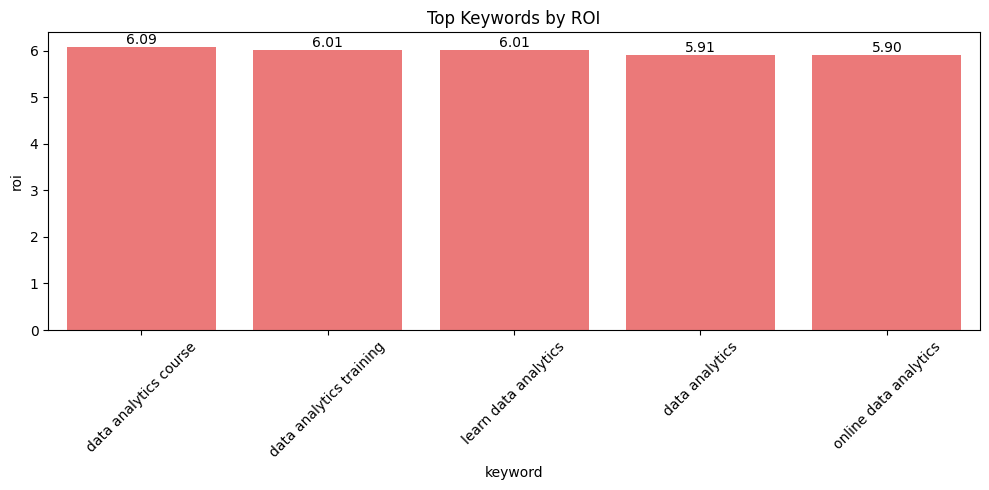

In [237]:
top_keywords = keyword_perf.sort_values(by='roi', ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(data=top_keywords, x='keyword', y='roi',color = 'red',alpha = 0.6)

plt.xticks(rotation=45)
plt.title('Top Keywords by ROI')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

#### Conversions By Device

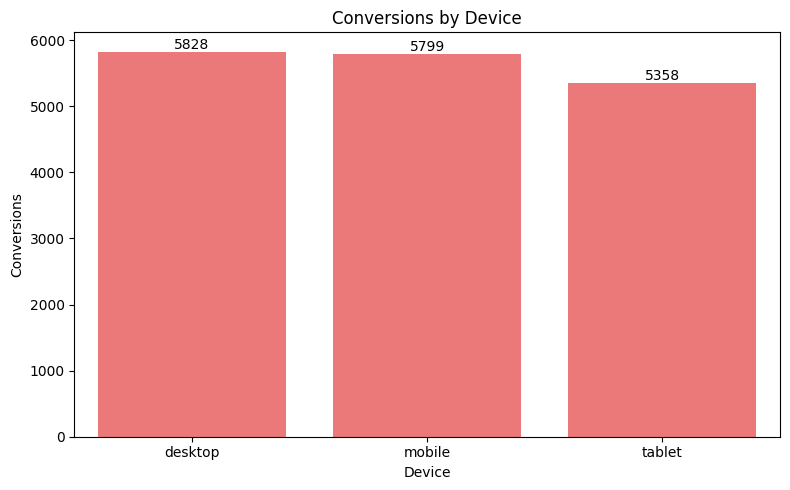

In [238]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=device_perf, x='device', y='conversions',color = 'red',alpha = 0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Conversions by Device')
plt.xlabel('Device')
plt.ylabel('Conversions')
plt.tight_layout()
plt.show()

#### Cost Vs Conversions

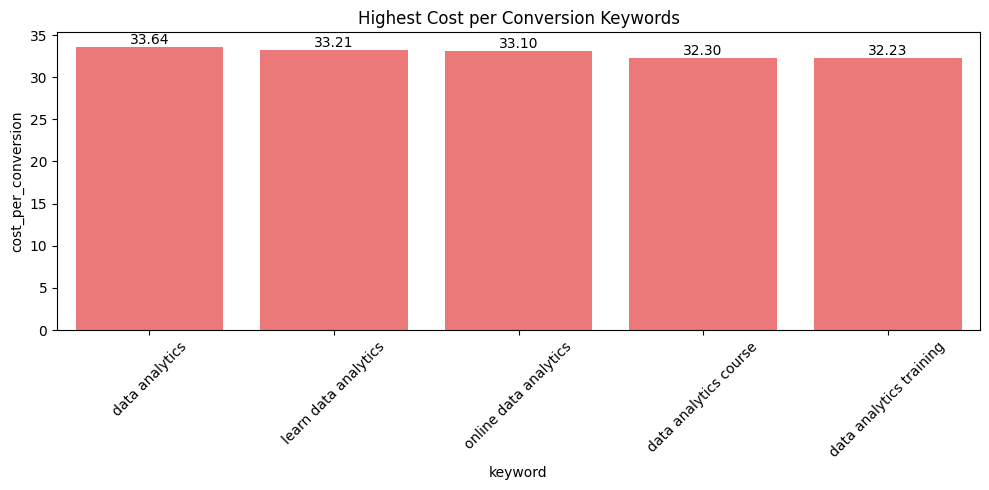

In [252]:
worst_keywords = keyword_perf.sort_values(by='cost_per_conversion', ascending=False).head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(data=worst_keywords, x='keyword', y='cost_per_conversion',color = 'red',alpha = 0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Highest Cost per Conversion Keywords')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

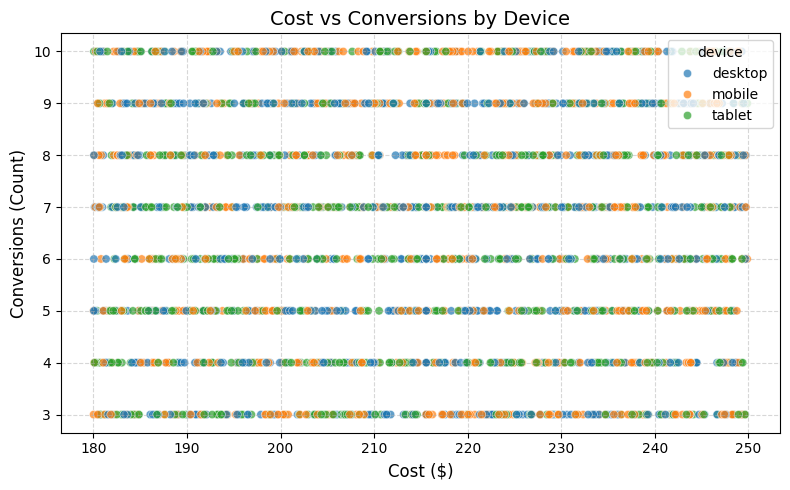

In [253]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='cost',
    y='conversions',
    hue='device',
    alpha=0.7
)

# ✅ Proper labels
plt.xlabel('Cost ($)', fontsize=12)
plt.ylabel('Conversions (Count)', fontsize=12)
plt.title('Cost vs Conversions by Device', fontsize=14)

# ✅ Improve readability
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()